# Análisis de correlación

Objetivos de la Clase:
* Comprender la Correlación: Definir la correlación y su importancia en el
análisis de datos.
* Calcular y Medir la Correlación: Aprender a utilizar las medidas de
correlación, y aplicar el método DataFrame.corr() de Pandas para calcular la
matriz de correlación.
* Manipular y Visualizar Datos: crear visualizaciones de correlaciones
utilizando Seaborn, como mapas de calor y diagramas de dispersión.

In [243]:
# Importamos librerias
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Dataset: Diamonds 
(usado en la Actividad Integradora Primer Parcial)

In [244]:
# Cargar dataset 
df=pd.read_csv("https://raw.githubusercontent.com/UADE-Python-Data-Science/583433_repo_oficial/refs/heads/main/Datasets/diamonds_clean.csv")
df.shape

(53794, 13)

In [245]:
df.head(2)

,carat,cut,color,clarity,depth,table,price,x,y,z,es_premium,categoria_precio,precio_por_quilate
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,True,Económico,1417.391304
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,True,Económico,1552.380952


In [246]:
# Renombrar columnas
df.rename(columns={"carat":"quilate",
                   "cut":"corte",
                   "price":"precio",
                   "depth": "profundidad"
                   }, inplace=True)

In [247]:
# Filtramos las columnas de interés
selected_columns = ["precio", "quilate", "profundidad", "corte", "color", "precio_por_quilate",  "categoria_precio"]
df = df[selected_columns]

In [248]:
# Inspeccioamos el df resultante
df.dtypes

precio                  int64
quilate               float64
profundidad           float64
corte                  object
color                  object
precio_por_quilate    float64
categoria_precio       object
dtype: object

# Análisis univariado (EDA)
En el análisis univariado, se analiza la distribución de una variable numérica, por ejemplo un histograma o boxplot:


In [249]:
def plot_histogramas_univariado():
    # Histogramas
    plt.figure(figsize=(10, 4))

    # Subplot Histograma precio
    plt.subplot(1, 3, 1)
    sns.histplot(data=df, x="precio", bins=10)

    # Subplot Histograma quilate
    plt.subplot(1, 3, 2)
    sns.histplot(data=df, x="quilate", bins="auto")

    # Subplot Histograma precio/quilate
    plt.subplot(1, 3, 3)
    sns.histplot(data=df, x="precio_por_quilate", bins="auto")

    # Título general centrado
    plt.suptitle(
        "Comparación de la distribución de tres variables numéricas",
        fontsize=14,
        ha="center"
    )
    plt.tight_layout()
    plt.show()

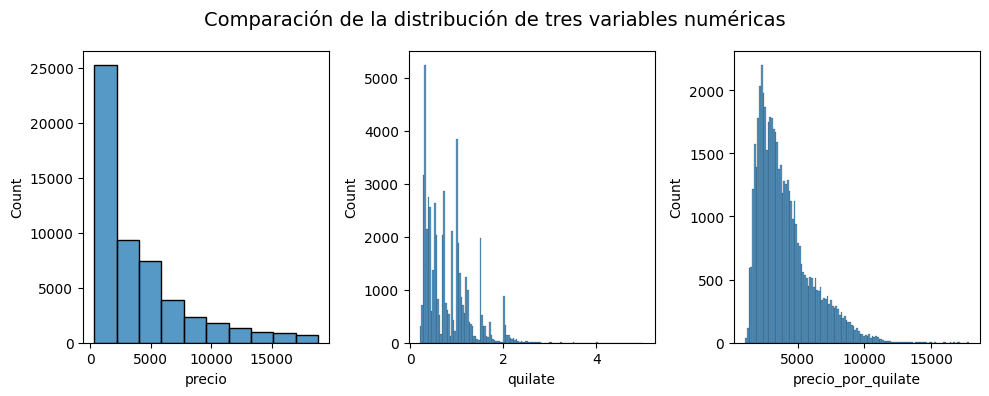

In [250]:
plot_histogramas_univariado()

In [251]:
def plot_boxplots_univariado():
    # Boxplots
    plt.figure(figsize=(10, 4))

    # Subplot Histograma precio
    plt.subplot(1, 3, 1)
    sns.boxplot(data=df, x="precio")

    # Subplot Histograma quilate
    plt.subplot(1, 3, 2)
    sns.boxplot(data=df, x="quilate")

    # Subplot Histograma precio/quilate
    plt.subplot(1, 3, 3)
    sns.boxplot(data=df, x="precio_por_quilate")

    # Título general centrado
    plt.suptitle(
        "Comparación de la distribución de tres variables numéricas",
        fontsize=14,
        ha="center"
    )
    plt.tight_layout()
    plt.show()

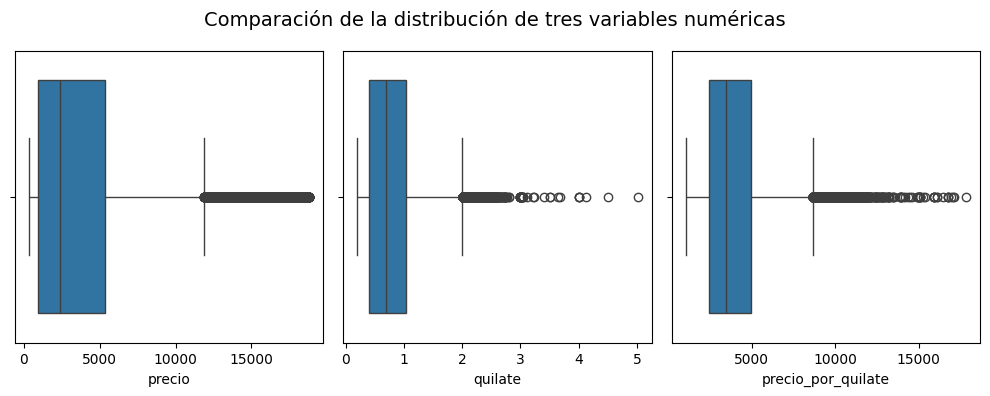

In [252]:
plot_boxplots_univariado()

Algunas observaciones del análisis univariado:
* El Histogrma nos permitió observar la distribución de las variables "precio" y "quilate". Precio tiene una distribución asimétrica (sesgo por derecha) o Skew positivo.
* El Boxplot, por otra parte presenta los valores atípicos (outliers). Dada la enorme asimetría mostrada en el histograma, es de esperar que haya valores atípicos.

Pero ahora nos hacemos la siguientes preguntas:
1. En el dataset tenemos una variable categórica: `corte`, la distribución del precio y del quilate, es la misma para todos?
2. Si nos enfocamos sólo en las variables numéricas, que relación existe entre el `precio` y el `quilate`, se podrá encontrar algún patrón o sacar alguna conclusión?
3. Si introducimos la otra variable numérica, `prfundidad`, que relación tendrá esta otra variable con el `precio`?

# Análisis bivariado

## Relación entre `precio` y `quilate` con el tipo de `corte`

Reemplazamos el gráfico `Histograma` por uno de `Densidad`.

La diferencia está en que el histograma representa la distribución de los datos mediante barras que muestran la frecuencia de las observaciones en determinados intervalos, mientras que el gráfico de densidad utiliza una curva continua y suavizada para estimar la distribución de probabilidad de la variable.

En el gráfico de densidad, el área total bajo la curva es igual a 1, lo que permite comparar distribuciones de variables con diferentes cantidades de observaciones.

In [253]:
def plot_histogramas():
    plt.figure(figsize=(10, 4))

    # Subplot Histograma precio
    plt.subplot(1, 2, 1)
    sns.kdeplot(data=df, x="precio", fill=True, hue="corte")

    # Subplot Histograma quilate
    plt.subplot(1, 2, 2)
    sns.kdeplot(data=df, x="quilate", fill=True, hue="corte")


    # Título general centrado
    plt.suptitle(
        "Distribución del precio y quilate según calidad del corte",
        fontsize=14,
        ha="center"
    )
    plt.tight_layout()
    plt.show()

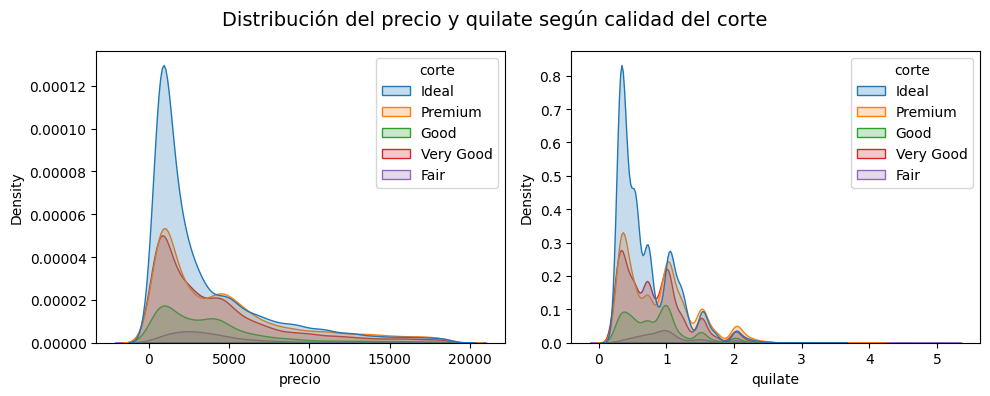

In [254]:
plot_histogramas()

In [255]:
def plot_boxplots():

    plt.figure(figsize=(12, 4))

    # Subplot precio
    plt.subplot(1, 2, 1)

    sns.boxplot(
        data=df,
        x="precio",
        hue="corte",
        legend=False
    )

    plt.title("Distribución del precio")
    plt.xlabel("Precio")

    # Subplot quilate
    plt.subplot(1, 2, 2)

    sns.boxplot(
        data=df,
        x="quilate",
        hue="corte"
    )

    plt.title("Distribución de quilate")
    plt.xlabel("Quilates")

    # Leyenda fuera del segundo subplot
    plt.legend(
        title="Corte",
        loc="upper left",
        bbox_to_anchor=(1.02, 1)
    )

    # Título general
    plt.suptitle(
        "Distribución del precio y quilate según calidad del corte",
        fontsize=14,
        ha="center"
    )

    # Reservar espacio a la derecha para la leyenda
    plt.tight_layout(rect=[0, 0, 0.85, 0.92])
    plt.show()

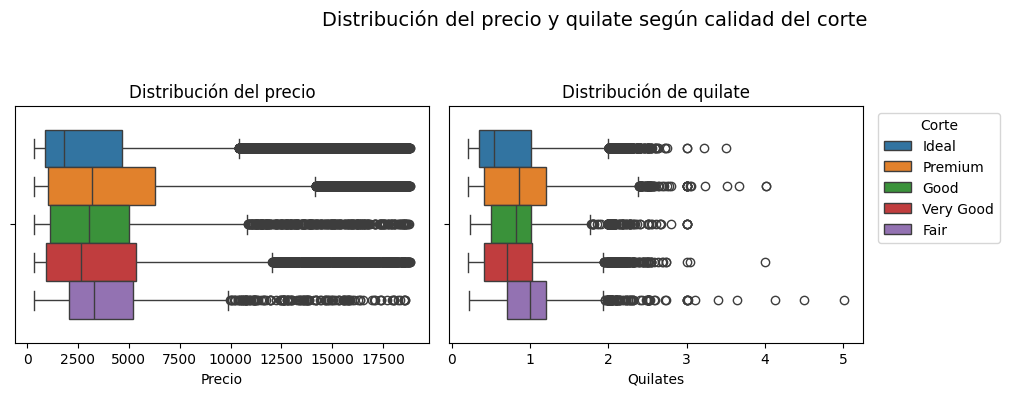

In [256]:
plot_boxplots()

## Relación entre variables numéricas

### Scatterplot

<Axes: xlabel='quilate', ylabel='precio'>

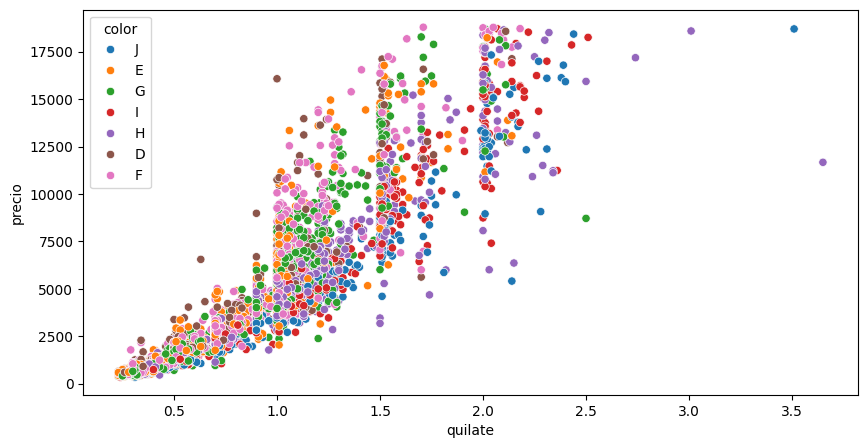

In [268]:
# Scatterplot o gráfico de dispersión
sample_df = df.sample( 5000 , random_state= 42 ) 

plt.figure(figsize=(10,5))
cortes = ["Fair", "Premium"]
# sns.pairplot(data=df, vars=v_numericas, hue="corte", hue_order=cortes)
sns.scatterplot(data=sample_df, x="quilate", y="precio", hue="color")

### Pairplot

<Figure size 1000x500 with 0 Axes>

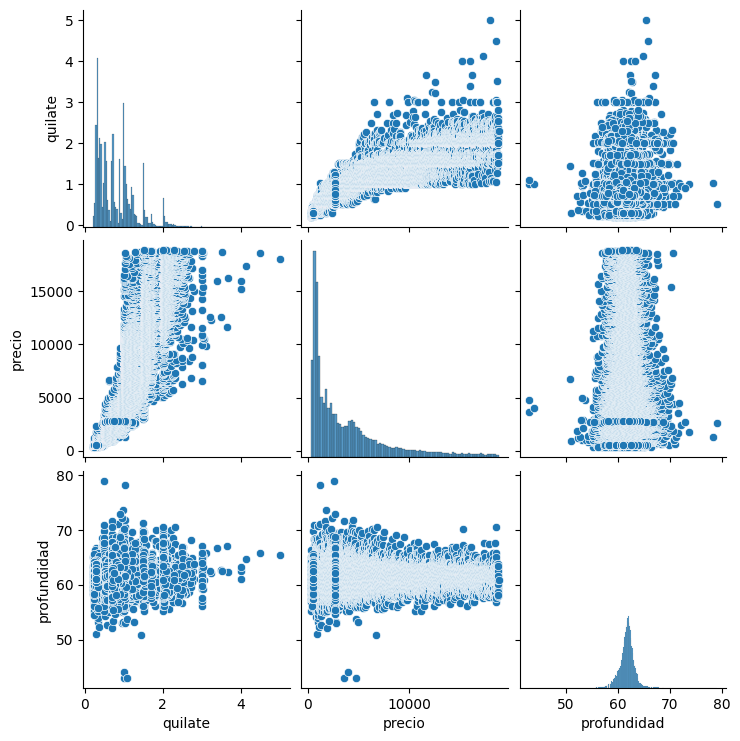

In [258]:
# Histograma de la distribución de Horas de sueño
plt.figure(figsize=(10,5))
v_numericas = ["quilate", "precio", "profundidad"]
cortes = ["Ideal", "Premium"]
# sns.pairplot(data=df, vars=v_numericas, hue="corte", hue_order=cortes)
sns.pairplot(data=df, vars=v_numericas)

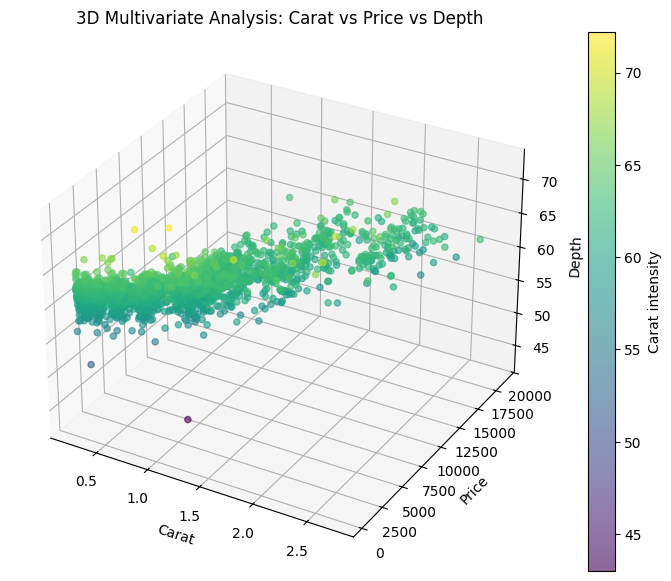

In [269]:
sample = df.sample(3000, random_state=42)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    sample['quilate'],
    sample['precio'],
    sample['profundidad'],
    c=sample['profundidad'],   # color encodes 4th dimension
    cmap='viridis',
    alpha=0.6
)

ax.set_title("3D Multivariate Analysis: Carat vs Price vs Depth")
ax.set_xlabel("Carat")
ax.set_ylabel("Price")
ax.set_zlabel("Depth")

plt.colorbar(scatter, label="Carat intensity")
plt.show()

In [ ]:
! pip install plotly

In [ ]:
! pip install --upgrade nbformat

In [277]:
import plotly.express as px

sample = df.sample(3000, random_state=42)

fig = px.scatter_3d(
    data_frame=sample,
    x="quilate",
    y="precio",
    z="profundidad",
    color="corte",
    opacity=0.6,
    title="Relación entre quilate, precio y profundidad"
)

fig.update_traces(
    marker=dict(size=3)
)

fig.show(renderer="browser")

**Conclusiones:**
De observar el gráfico de dispersión, scatterplot, entre precio vs quilate y precio vs profundidad, a simple vista, pareciera que hay una relación lineal más marcada en la primero que en el segundo caso.

La pregunta entonces es, podemos cuantificarlo?

## Covarianza

La covarianza mide la existencia de asociación lineal entre dos variables; es decir, si el comportamiento de las variables se mueve en la misma dirección o en direcciones opuestas.
<BR>
Se calcula de la siguiente manera:
<BR>
$$
\operatorname{Cov}(X,Y) =
\frac{\sum_{i=1}^{n}(x_i-\bar{X})(y_i-\bar{Y})}{n-1}
$$

In [259]:
# A partir de la fórmula, calculamos la covarianza entre pasos_diarios y las horas_sueno
cov_xy = ((df["precio"] - df["precio"].mean()) *
          (df["quilate"] - df["quilate"].mean())).sum() / (len(df) - 1)
cov_xy

np.float64(1739.8228340498872)

In [260]:
# O bien podemos usar el método de pandas cov de la siguiente manera:
df["precio"].cov(df["quilate"])

np.float64(1739.8228340498888)

Agregar la variable Nivel_estres al dataset y analizar el comportamiento Horas_sueno Vs Nivel_estres

In [261]:
# Y que sucede entre las Horas_sueno y el Nivel_estres
df["precio"].cov(df["profundidad"])

np.float64(-63.00005441358405)

## Interpretación

* Una covarianza positiva indica que ambas variables se mueven la
misma dirección (ambas crecen o ambas decrecen).

* Una covarianza negativa indica que las variables se mueven en direcciones opuestas (cuando una crece, la otra decrece).

* Una covarianza nula indica que no hay una relación lineal entre las variables. En este caso se dice que las variables son no correlacionadas.

Cuidado: la magnitud de la covarianza depende de las unidades (no está normalizada). Por eso no podemos comparar covarianzas de variables en distintas escalas

Analicemos:
* El signo de las covarianzas nos indican en que sentido se mueven las variables, pero: ¿cómo podemos determinar el grado de asociación lineal entre las variables, es decir que tan relacionadas están???

## Correlación: fuerza de la asociación lineal


Dadas dos muestras:
* X = (x1, x2, x3, ..., xn)
* Y = (y1, y2, y3, ..., yn)
<BR>
Se define el Coeficiente de Correlación de Pearson como:

$$
\operatorname{Corr}(X,Y) =
\frac{\operatorname{Cov}(X,Y)}{s_X \cdot s_Y}
$$

donde:
* Corr(X,Y): es el coeficiente de correlación de Pearson
* Cov(X,Y): es la covarianza entre X e Y
* sX: es el desvío standard de X
* sY: es el desvío standard de Y


Interpretación:

La correlación toma valores en el intervalo [−1, 1].
* Corr(X, Y) = 1 indica una relación lineal directa perfecta, donde los datos están sobre una recta de pendiente positiva.
* Corr(X, Y ) = -1 indica una relación lineal inversa perfecta, donde los datos están sobre una recta de pendiente negativa.
* Corr(X, Y ) = 0 indica que no existe una relación lineal entre los datos.


En particular:
* 0 ≤ |Corr(X, Y )| ≤ 0.25 =⇒ No hay relación lineal
* 0.25 < |Corr(X, Y )| ≤ 0.50 =⇒ La relación lineal es débil
* 0.50 < |Corr(X, Y )| ≤ 0.75 =⇒ La relación lineal es moderada
* 0.75 < |Corr(X, Y )| ≤ 1 =⇒ La relación lineal es fuerte

In [262]:
# Calculemos la correlación entre Horas_sueno y Pasos_diarios
df["precio"].corr(df["quilate"])

np.float64(0.9215483214030127)

In [263]:
# Calculemos la correlación entre Horas_sueno y el Nivel_estres
df["precio"].corr(df["profundidad"])

np.float64(-0.01104752186786847)

## Matríz de correlación

In [264]:
# Calculamos la matriz de correlación para el Dataframe df
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,precio,quilate,profundidad,precio_por_quilate
precio,1.000000,0.921548,-0.011048,0.912646
quilate,0.921548,1.000000,0.027861,0.770222
profundidad,-0.011048,0.027861,1.000000,-0.035840
precio_por_quilate,0.912646,0.770222,-0.035840,1.000000


In [265]:
# O bien podemos extraer las variables que nos interesan y realizar gráficos separados
corr_matrix[["precio"]]

,precio
precio,1.000000
quilate,0.921548
profundidad,-0.011048
precio_por_quilate,0.912646


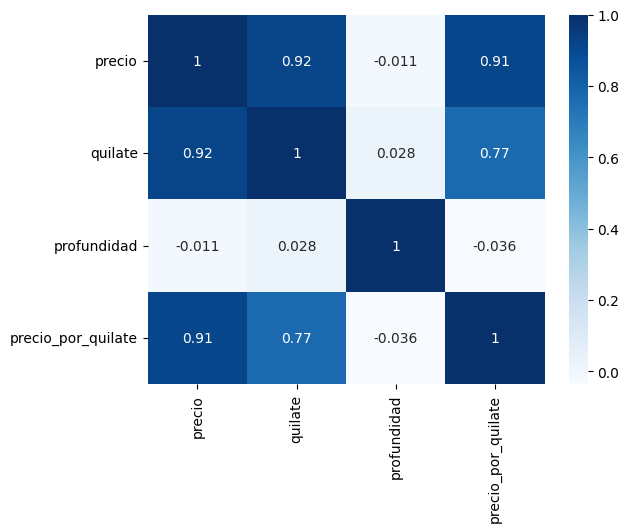

In [266]:
# Creamos un mapa de calor
sns.heatmap(corr_matrix, annot=True, cmap="Blues") # cmap = Blues, Greens, rocket
plt.show()

# Material complementario

[Blog Kaggle sobre correlación](https://www.kaggle.com/code/mukeshchoudhary/correlation)

[Advanced EDA diamonds dataset](https://medium.com/codetodeploy/advanced-eda-techniques-every-data-scientist-should-know-016e70af701a)